
#**Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

##**Edición 2026**

---

# Trabajo práctico entregable - Parte 2

INTEGRANTES

Rafael Pignata

María José Kanagusuku

María Valeria Syera

Nicolas Mansutti

In [ ]:
import io
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

#seaborn.set_context('talk')

## Lectura del dataset

En la notebook 00 se explican los detalles de la siguiente sección.

In [ ]:
url = 'https://raw.githubusercontent.com/DiploDatos/AnalisisyVisualizacion/refs/heads/master/sysarmy_survey_2026_processed.csv'
df = pd.read_csv(url)

In [ ]:
df[:3]

,work_province,work_dedication,work_contract_type,salary_monthly_BRUTO,salary_monthly_NETO,salary_in_usd,salary_last_dollar_value,salary_has_bonus,salary_bonus_tied_to,salary_inflation_adjustment,...,salary_on_call_duty_charge,aclara_el_numero_que_ingresaste_en_el_campo_anterior,salir_o_seguir_contestando_sobre_estudios,profile_age,profile_gender,profile_previous_survey,company_best_companies,sueldo_dolarizado,work_seniority,_sal
0,Mendoza,Full-Time,Staff (planta permanente),3000000.0,2400000.0,Mi sueldo está dolarizado (pero cobro en moned...,1300,No,Performance individual,No,...,NaN,NaN,NaN,45,Mujer Cis,Sí,NaN,True,Senior,3000000.0
1,Santa Fe,Full-Time,Contractor,5000000.0,5000000.0,Cobro todo el salario en dólares,1400,No,No recibo bono,No,...,NaN,NaN,NaN,50,Mujer Cis,Sí,NaN,True,Senior,5000000.0
2,Buenos Aires,Full-Time,Tercerizado (trabajo a través de consultora o ...,4600000.0,3600000.0,Cobro parte del salario en dólares,1436,No,No recibo bono,Uno,...,0.0,Porcentaje de mi sueldo bruto,Terminar encuesta,36,Mujer Cis,Sí,NaN,True,Senior,4600000.0


In [ ]:
df.work_seniority.unique()

array(['Senior', 'Semi-Senior', 'Junior'], dtype=object)

In [ ]:
df.loc[:,'profile_g'] = df.profile_gender.replace({'Hombre Cis': 'Varón cis','Mujer Cis': 'Mujer cis','Queer':'Diversidades','Trans':'Diversidades','Queer':'Diversidades','Lesbiana':'Diversidades','Agénero':'Diversidades'}).fillna(False)

In [ ]:
alpha = 0.05

In [ ]:
# =============================================================================
# Vamos a poner una cota inferior y superior en el salario NETO.
# =============================================================================
og_top= 15000000
og_bottom= 100000

df_salary_filtered= df[
    (og_top>df.salary_monthly_NETO)&(df.salary_monthly_NETO > og_bottom)
    ]

# =============================================================================
# Vamos a limpiar tambien por el salario NETO, vamos a sacarnos los
# outliers/raros/absurdos, teniendo en cuenta el mismo criterio del Entregable 1
# =============================================================================

# bruto_quartile_top= df.salary_monthly_BRUTO.quantile(0.95)
# neto_quartile_top= df.salary_monthly_NETO.quantile(0.95)

# bruto_quartile_bottom= df.salary_monthly_BRUTO.quantile(0.05)
# neto_quartile_bottom= df.salary_monthly_NETO.quantile(0.05)

# df_salary_filtered= df[(df.salary_monthly_BRUTO < bruto_quartile_top) #chau cola 95%
#                   & (df.salary_monthly_NETO < neto_quartile_top) #chau cola 95%
#                   & (df.salary_monthly_NETO <= df.salary_monthly_BRUTO) #chau netos más grandes (absurdo)
#                   & (df.salary_monthly_NETO >= neto_quartile_bottom) #chau cola 5%
#                   & (df.salary_monthly_BRUTO >= bruto_quartile_bottom) #chau cola 5%
#                   & (df.salary_monthly_BRUTO.notna()) #chau absurdo
#                   & (df.salary_monthly_NETO.notna())].copy() #chau absurdo

In [ ]:
# =============================================================================
# Creamos máscaras para el género y el seniority
# =============================================================================

is_man = df_salary_filtered.profile_g == 'Varón cis'
is_woman = df_salary_filtered.profile_g == 'Mujer cis'
is_diversities = df_salary_filtered.profile_g == 'Diversidades'

sen = df_salary_filtered.work_seniority == 'Senior'
semi = df_salary_filtered.work_seniority == 'Semi-Senior'
jun = df_salary_filtered.work_seniority == 'Junior'

In [ ]:
# =============================================================================
# Creamos los arrays para cada genero por seniority
# =============================================================================

# Hombres
Hom_sen  = df_salary_filtered[is_man & sen]['salary_monthly_NETO']
Hom_semi = df_salary_filtered[is_man & semi]['salary_monthly_NETO']
Hom_jun  = df_salary_filtered[is_man & jun]['salary_monthly_NETO']

# Mujeres
Muj_sen  = df_salary_filtered[is_woman & sen]['salary_monthly_NETO']
Muj_semi = df_salary_filtered[is_woman & semi]['salary_monthly_NETO']
Muj_jun  = df_salary_filtered[is_woman & jun]['salary_monthly_NETO']

# Diversidades
Div_sen  = df_salary_filtered[is_diversities & sen]['salary_monthly_NETO']
Div_semi = df_salary_filtered[is_diversities & semi]['salary_monthly_NETO']
Div_jun  = df_salary_filtered[is_diversities & jun]['salary_monthly_NETO']


In [ ]:
# =============================================================================
# Mostramos algunos estadísticos para los distintos géneros y los dividimos por
# 1.e6 (1 millón) para facilitar la lectura
# =============================================================================

factor= 1000000
print(f"Salario promedio masculino para senior (en millones de pesos) : {Hom_sen.mean()/factor}")
print(f"Mediana (en millones de pesos): {Hom_sen.median()/factor}")
print(f"Desviación estándar (en millones de pesos): {Hom_sen.std()/factor}")

Salario promedio masculino para senior (en millones de pesos) : 3.9356291607389164
Mediana (en millones de pesos): 3.5
Desviación estándar (en millones de pesos): 2.2249194277860123


In [ ]:
print(f"Salario promedio femenino para senior (en millones de pesos): {Muj_sen.mean()/factor}")
print(f"Mediana (en millones de pesos): {Muj_sen.median()/factor}")
print(f"Desviación estándar (en millones de pesos): {Muj_sen.std()/factor}")

Salario promedio femenino para senior (en millones de pesos): 3.3264194982727275
Mediana (en millones de pesos): 3.0
Desviación estándar (en millones de pesos): 1.6617261855333523


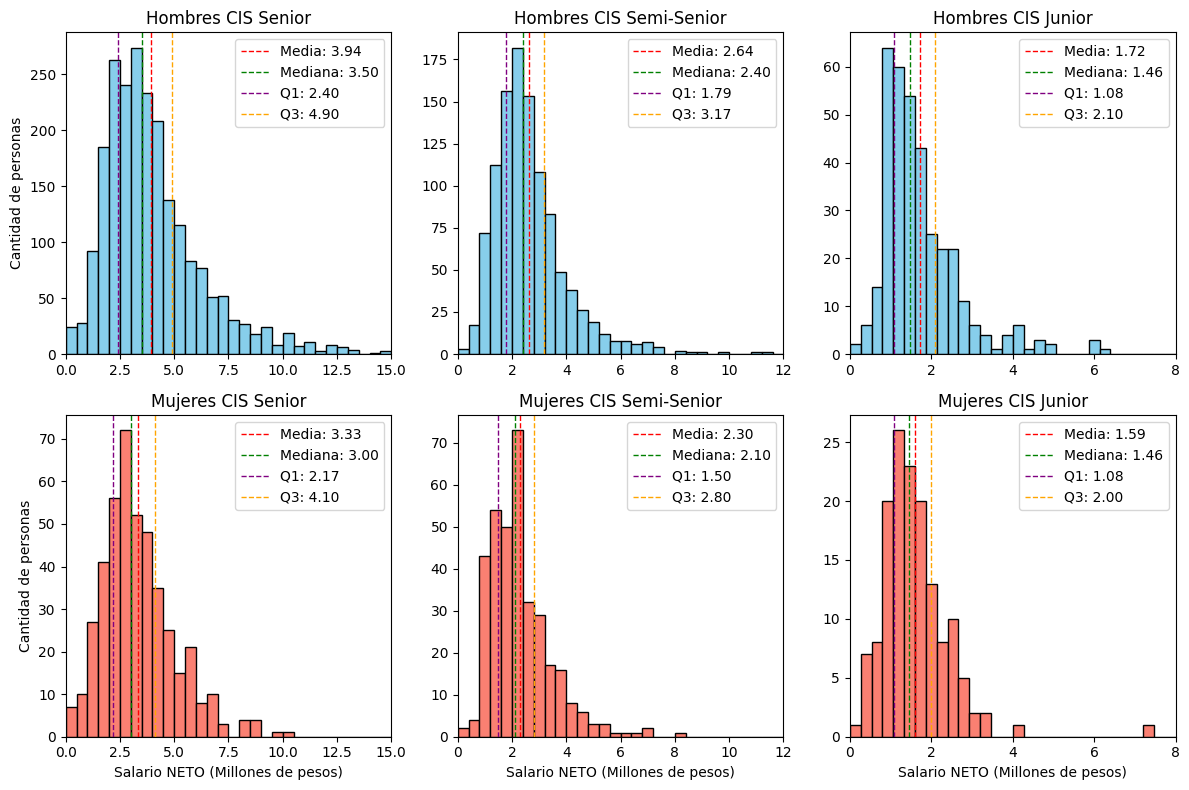

In [ ]:
# =============================================================================
# Creamos un histograma para analizar la distribución de los salarios de los
# diferentes grupos
# =============================================================================
# fig, axes = plt.subplots(3, 2, figsize=(15, 15), sharey=False)
fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharey=False)

def plot_hist_with_stats(ax, data, title, color, bins=30, show_xticklabels=True, hist_range=None):
    ax.hist(data, bins=bins, color=color, edgecolor='black', density=False, range=hist_range)
    ax.set_title(title)
    ax.set_xlabel('')

    # Calcular estadisticos
    data_mean = data.mean()
    data_median = data.median()
    data_q1 = np.percentile(data, 25)
    data_q3 = np.percentile(data, 75)

    # Plotear lineas de estadisticos
    ax.axvline(data_mean, color='red', linestyle='dashed', linewidth=1, label=f'Media: {data_mean:.2f}')
    ax.axvline(data_median, color='green', linestyle='dashed', linewidth=1, label=f'Mediana: {data_median:.2f}')
    ax.axvline(data_q1, color='purple', linestyle='dashed', linewidth=1, label=f'Q1: {data_q1:.2f}')
    ax.axvline(data_q3, color='orange', linestyle='dashed', linewidth=1, label=f'Q3: {data_q3:.2f}')
    ax.legend()

    if not show_xticklabels:
        ax.tick_params(axis='x', labelbottom=False)

# Plots de cada grupo (histogramas)
# Hombres
plot_hist_with_stats(axes[0,0], Hom_sen/factor, 'Hombres CIS Senior', 'skyblue', show_xticklabels=True, hist_range=(0.,15.))
plot_hist_with_stats(axes[0,1], Hom_semi/factor, 'Hombres CIS Semi-Senior', 'skyblue', show_xticklabels=True, hist_range=(0.,12.))
plot_hist_with_stats(axes[0,2], Hom_jun/factor, 'Hombres CIS Junior', 'skyblue', show_xticklabels=True,  hist_range=(0.,8.))
axes[0,0].set_xlim(0,15)
axes[0,1].set_xlim(0,12)
axes[0,2].set_xlim(0,8)

# Mujeres
plot_hist_with_stats(axes[1,0], Muj_sen/factor, 'Mujeres CIS Senior', 'salmon', show_xticklabels=True, hist_range=(0.,15.))
plot_hist_with_stats(axes[1,1], Muj_semi/factor, 'Mujeres CIS Semi-Senior', 'salmon', show_xticklabels=True, hist_range=(0.,12.))
plot_hist_with_stats(axes[1,2], Muj_jun/factor, 'Mujeres CIS Junior', 'salmon', show_xticklabels=True, hist_range=(0.,8.))
axes[1,0].set_xlim(0,15)
axes[1,1].set_xlim(0,12)
axes[1,2].set_xlim(0,8)

# # Senior
# plot_hist_with_stats(axes[0,0], Hom_sen, 'Hombres CIS Senior', 'skyblue', show_xticklabels=True)
# plot_hist_with_stats(axes[0,1], Muj_sen, 'Mujeres CIS Senior', 'salmon', show_xticklabels=True)

# # Semi-Senior
# plot_hist_with_stats(axes[1,0], Hom_semi, 'Hombres CIS Semi-Senior', 'skyblue', show_xticklabels=True)
# plot_hist_with_stats(axes[1,1], Muj_semi, 'Mujeres CIS Semi-Senior', 'salmon', show_xticklabels=True)

# # Junior
# plot_hist_with_stats(axes[2,0], Hom_jun, 'Hombres CIS Junior', 'skyblue', show_xticklabels=True)
# plot_hist_with_stats(axes[2,1], Muj_jun, 'Mujeres CIS Junior', 'salmon', show_xticklabels=True)

# Labels Comunes
# axes[2,0].set_xlabel('Salario NETO')
# axes[2,0].set_ylabel('Cantidad de personas')
# axes[2,1].set_xlabel('Salario NETO')

axes[1,0].set_xlabel('Salario NETO (Millones de pesos)')
axes[1,1].set_xlabel('Salario NETO (Millones de pesos)')
axes[1,2].set_xlabel('Salario NETO (Millones de pesos)')
axes[0,0].set_ylabel('Cantidad de personas')
axes[1,0].set_ylabel('Cantidad de personas')

plt.tight_layout()
plt.show()

## Ejercicio 1: Estimación

**Consigna:**  Calcular una estimación puntual y un intervalo de confianza de nivel (1-alpha) para la resta entre la media del salario Neto para Hombres y la media del salario Neto para mujeres (diferencia de las medias entre el grupoA y grupoB).
¿Cómo se relaciona este intervalo de confianza con el test de hipótesis para diferencia de medias?

In [ ]:
# ===== SENIOR =====
mean_H_sen = Hom_sen.mean()
mean_M_sen = Muj_sen.mean()
diff_sen = mean_H_sen - mean_M_sen

print("==== Senior ====")
print(f"Media Varones: ${mean_H_sen/factor:.2f}M")
print(f"Media Mujeres: ${mean_M_sen/factor:.2f}M")
print(f"Mediana Varones: ${Hom_sen.median()/factor:.2f}M")
print(f"Mediana Mujeres: ${Muj_sen.median()/factor:.2f}M")
print(f"Diferencia: ${diff_sen:.0f}\n")


# ===== SEMI-SENIOR =====
mean_H_semi = Hom_semi.mean()
mean_M_semi = Muj_semi.mean()
diff_semi = mean_H_semi - mean_M_semi

print("==== Semi-Senior ====")
print(f"Media Varones: ${mean_H_semi/factor:.2f}M")
print(f"Media Mujeres: ${mean_M_semi/factor:.2f}M")
print(f"Mediana Varones: ${Hom_semi.median()/factor:.2f}M")
print(f"Mediana Mujeres: ${Muj_semi.median()/factor:.2f}M")
print(f"Diferencia: ${diff_semi:.0f}\n")


# ===== JUNIOR =====
mean_H_jun = Hom_jun.mean()
mean_M_jun = Muj_jun.mean()
diff_jun = mean_H_jun - mean_M_jun

print("==== Junior ====")
print(f"Media Varones: ${mean_H_jun/factor:.2f}M")
print(f"Media Mujeres: ${mean_M_jun/factor:.2f}M")
print(f"Mediana Varones: ${Hom_jun.median()/factor:.2f}M")
print(f"Mediana Mujeres: ${Muj_jun.median()/factor:.2f}M")
print(f"Diferencia: ${diff_jun:.0f}")

==== Senior ====
Media Varones: $3.94M
Media Mujeres: $3.33M
Mediana Varones: $3.50M
Mediana Mujeres: $3.00M
Diferencia: $609210

==== Semi-Senior ====
Media Varones: $2.64M
Media Mujeres: $2.30M
Mediana Varones: $2.40M
Mediana Mujeres: $2.10M
Diferencia: $342922

==== Junior ====
Media Varones: $1.72M
Media Mujeres: $1.59M
Mediana Varones: $1.46M
Mediana Mujeres: $1.46M
Diferencia: $130900


A partir de los resultados, podemos observar las siguientes estimaciones puntuales de la diferencia de salario neto promedio (Varones - Mujeres) para cada nivel de seniority:

*   **Senior**: Los varones ganan en promedio ~\$601,000 más que las mujeres.
*   **Semi-Senior**: Los varones ganan en promedio ~\$340,000 más que las mujeres.
*   **Junior**: Los varones ganan en promedio ~\$130,000 más que las mujeres.

Estos valores nos proporcionan una estimación puntual de la brecha salarial por nivel de experiencia. Sin embargo, es importante recordar que estas son solo estimaciones puntuales y no incluyen la incertidumbre asociada a la variabilidad de los datos.

In [ ]:
def calculate_diff_means_confidence_interval(groupA, groupB, diff_means_val, alpha= 0.05):
    n_A = len(groupA)
    n_B = len(groupB)

    std_A = groupA.std()
    std_B = groupB.std()

    # Error estándar de la diferencia (pooled standard error, assuming independent samples)
    se_diff = np.sqrt((std_A**2 / n_A) + (std_B**2 / n_B))

    # Valor crítico para (1-alpha) confidence level (for a two-tailed interval)
    z_value = stats.norm.ppf(1 - alpha/2)

    # Intervalo de confianza
    lower = diff_means_val - z_value * se_diff
    upper = diff_means_val + z_value * se_diff

    return se_diff, lower, upper

# ===== Grupo Senior =====
print("==== Grupo Senior (Varones vs Mujeres) ====")
se_diff_sen, lower_sen, upper_sen = calculate_diff_means_confidence_interval(Hom_sen, Muj_sen, diff_sen)
print(f"Estimación puntual de la diferencia: ${diff_sen:.0f}")
if not np.isnan(se_diff_sen):
    print(f"Error estándar: {se_diff_sen:.0f}")
    print(f"IC {(1-alpha)*100:.0f}%: [{lower_sen:.0f}, {upper_sen:.0f}]\n")
else:
    print("No hay suficientes datos para calcular el IC para Senior.\n")

# ===== Grupo Semi-Senior =====
print("==== Grupo Semi-Senior (Varones vs Mujeres) ====")
se_diff_semi, lower_semi, upper_semi = calculate_diff_means_confidence_interval(Hom_semi, Muj_semi, diff_semi)
print(f"Estimación puntual de la diferencia: ${diff_semi:.0f}")
if not np.isnan(se_diff_semi):
    print(f"Error estándar: {se_diff_semi:.0f}")
    print(f"IC {(1-alpha)*100:.0f}%: [{lower_semi:.0f}, {upper_semi:.0f}]\n")
else:
    print("No hay suficientes datos para calcular el IC para Semi-Senior.\n")

# ===== Grupo Junior =====
print("==== Grupo Junior (Varones vs Mujeres) ====")
se_diff_jun, lower_jun, upper_jun = calculate_diff_means_confidence_interval(Hom_jun, Muj_jun, diff_jun)
print(f"Estimación puntual de la diferencia: ${diff_jun:.0f}")
if not np.isnan(se_diff_jun):
    print(f"Error estándar: {se_diff_jun:.0f}")
    print(f"IC {(1-alpha)*100:.0f}%: [{lower_jun:.0f}, {upper_jun:.0f}]\n")
else:
    print("No hay suficientes datos para calcular el IC para Junior.\n")


==== Grupo Senior (Varones vs Mujeres) ====
Estimación puntual de la diferencia: $609210
Error estándar: 92155
IC 95%: [428588, 789831]

==== Grupo Semi-Senior (Varones vs Mujeres) ====
Estimación puntual de la diferencia: $342922
Error estándar: 73858
IC 95%: [198163, 487680]

==== Grupo Junior (Varones vs Mujeres) ====
Estimación puntual de la diferencia: $130900
Error estándar: 85337
IC 95%: [-36357, 298157]



A partir del cálculo de los intervalos de confianza para la diferencia de medias (salario neto varones - salario neto mujeres) por cada nivel de seniority, se obtuvieron los siguientes resultados:

*   **Senior**: La diferencia puntual es de \$609210, con un IC del 95% de [\$428588, \$789831]. Dado que este intervalo no incluye el cero (que los salarios promedios de hombres y mujeres son iguales) y se encuentra completamente en valores positivos, sugiere que los varones Senior perciben salarios significativamente mayores que las mujeres Senior.

*   **Semi-Senior**: La diferencia puntual es de \$342922, con un IC del 95% de [\$198163, \$487680]. Similar al grupo Senior, este intervalo no contiene el cero y es totalmente positivo, indicando que los varones Semi-Senior tienen salarios significativamente más altos que las mujeres Semi-Senior.

*   **Junior**: La diferencia puntual es de \$130900, con un IC del 95% de [\$-36357, \$298157]. En este caso, el intervalo de confianza **sí contiene el cero**. Esto significa que, a un nivel de confianza del 95%, no podemos afirmar que exista una diferencia estadísticamente significativa en los salarios netos promedio entre varones y mujeres en la categoría Junior.

En resumen, los resultados sugieren una brecha salarial significativa a favor de los varones en los niveles Senior y Semi-Senior, mientras que en el nivel Junior, la evidencia no es concluyente para afirmar una diferencia significativa.

La relación entre el intervalo de confianza y el test de hipótesis es directa. En el caso de un test bilateral para evaluar si la diferencia de medias es igual a cero ($H_0: \mu_1 - \mu_2 = 0$), el intervalo de confianza proporciona una forma equivalente de tomar la decisión.

Si el valor hipotético (en este caso 0) pertenece al intervalo de confianza, no se rechaza la hipótesis nula. En cambio, si el valor no pertenece al intervalo, se rechaza $H_0$.

En este caso, como el intervalo de confianza no incluye el 0, esto es consistente con rechazar la hipótesis nula y concluir que existe una diferencia estadísticamente significativa entre los salarios promedio de varones y mujeres.

## Ejercicio 2: Test de hipótesis



### 2.1 Formalización

Describir formalmente los distintos componentes de un test de hipótesis para comprobar si la distribución de los salarios es distinta entre los grupos A y B.

**Hipótesis Nula**

$H_0=...$

**Estadístico (Pivote)**
  * Identificar el estadístico
  * Escribir qué distribución tiene bajo $H_0$


### Hipótesis nula

Se quiere evaluar si existe diferencia en los salarios promedio entre varones y mujeres (para diferentes seniority).

$$
H_0: \mu_A - \mu_B = 0
$$

$$
H_1: \mu_A - \mu_B \neq 0
$$

donde:

- $\mu_A$: media poblacional del salario neto para varones  
- $\mu_B$: media poblacional del salario neto para mujeres  

---

### Estadístico (pivote)

Se utiliza como estadístico la diferencia de medias muestrales estandarizada:

$$
t = \frac{\bar{X}_A - \bar{X}_B}{\sqrt{\frac{S_A^2}{n_A} + \frac{S_B^2}{n_B}}}
$$

donde:

- $\bar{X}_A$, $\bar{X}_B$: medias muestrales  
- $S_A^2$, $S_B^2$: varianzas muestrales  
- $n_A$, $n_B$: tamaños muestrales  

---

### Distribución bajo $H_0$

Bajo la hipótesis nula, como no se conocen las varianzas poblacionales, el estadístico sigue una distribución $t$ de Student utilizando la aproximación de Welch, ya que no podemos asumir, a priori, que las varianzas poblacionales sean iguales:

$$
t \sim t(ν)
$$
donde $ν$ indica los grados de libertad.
Menos grados de libertad significa que la distribución $t$ tendrá "colas más pesadas", lo que indica una mayor probabilidad en los extremos, haciendo que el valor de $t$ tenga que ser más alto para rechazar la hipótesis nula.

En el código que presentamos más abajo podremos ver los grados de libertad que fueron utilizados.

### Criterio de Rechazo
Para saber si rechazamos $H_0$, trabajaremos con un $α=0.05$, un valor bastante estandard para pruebas de test de hipótesis. Así, si el p-valor que calculamos (ie la probabilidad de tener datos tan extremos como los observados suponiendo $H_0$) es menor a 0.05 (es decir, menor al 5%), rechazamos $H_0$.


### 2.2 P-valor

1. Calcule el p-valor y decida si rechazar o no la hipótesis nula.
2. Interprete el resultado.

Links útiles:
* [Test de hipótesis usando scipy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html)
* [Test de Welch](http://daniellakens.blogspot.com/2015/01/always-use-welchs-t-test-instead-of.html)

In [ ]:
def reject_null_hypothesis(p_value, alpha=0.05):
  if p_value < alpha:
    return("Rechazamos H0")
  else:
    return("No tenemos suficiente evidencia para rechazar H0")

# ===== Grupo Senior =====
print("===== Grupo Senior (Varones vs Mujeres) =====")

welch_senior = stats.ttest_ind(Hom_sen, Muj_sen, equal_var=False)
print(f"Estadístico t: {welch_senior.statistic:.2f}")
print(f"p-valor: {welch_senior.pvalue:.4e}")
print(f"grados de libertad: {welch_senior.df:.2f}")
print(reject_null_hypothesis(welch_senior.pvalue))

# ===== Grupo Semi-Senior =====
print("===== Grupo Semi-Senior (Varones vs Mujeres) =====")
welch_semi = stats.ttest_ind(Hom_semi, Muj_semi, equal_var=False)
print(f"Estadístico t: {welch_semi.statistic:.2f}")
print(f"p-valor: {welch_semi.pvalue:.4e}")
print(f"grados de libertad: {welch_semi.df:.2f}")
print(reject_null_hypothesis(welch_semi.pvalue))

# ===== Grupo Junior =====
print("===== Grupo Junior (Varones vs Mujeres) =====")
welch_junior = stats.ttest_ind(Hom_jun, Muj_jun, equal_var=False)
print(f"Estadístico t: {welch_junior.statistic:.2f}")
print(f"p-valor: {welch_junior.pvalue:.4e}")
print(f"grados de libertad: {welch_junior.df:.2f}")
print(reject_null_hypothesis(welch_junior.pvalue))

===== Grupo Senior (Varones vs Mujeres) =====
Estadístico t: 6.61
p-valor: 7.0665e-11
grados de libertad: 784.67
Rechazamos H0
===== Grupo Semi-Senior (Varones vs Mujeres) =====
Estadístico t: 4.64
p-valor: 4.1226e-06
grados de libertad: 679.61
Rechazamos H0
===== Grupo Junior (Varones vs Mujeres) =====
Estadístico t: 1.53
p-valor: 1.2604e-01
grados de libertad: 317.98
No tenemos suficiente evidencia para rechazar H0


Se realizó un test t de Welch (`equal_var=False`) para comparar los salarios promedio entre varones y mujeres para cada nivel de seniority:

*   **Senior**: Se obtuvo un estadístico de prueba de $t = 6.61$ y un p-valor de $7.0665 \times 10^{-11}$. Dado que este p-valor es significativamente menor que el nivel de significancia $\alpha = 0.05$, se **rechaza la hipótesis nula**. Esto indica que existe evidencia estadísticamente significativa para afirmar que los salarios promedio entre varones y mujeres Senior son diferentes.

*   **Semi-Senior**: Se obtuvo un estadístico de prueba de $t = 4.64$ y un p-valor de $4.1226 \times 10^{-6}$. Similar al grupo Senior, este p-valor es significativamente menor que $\alpha = 0.05$, por lo que se **rechaza la hipótesis nula**. Esto sugiere que hay una diferencia estadísticamente significativa en los salarios promedio entre varones y mujeres Semi-Senior.

*   **Junior**: Se obtuvo un estadístico de prueba de $t = 1.53$ y un p-valor de $0.1260$. En este caso, el p-valor ($0.1260$) es mayor que $\alpha = 0.05$, por lo que **no tenemos suficiente evidencia para rechazar la hipótesis nula**. Esto significa que, no podemos afirmar que exista una diferencia estadísticamente significativa en los salarios netos promedio entre varones y mujeres en la categoría Junior.

Estos resultados son consistentes con los intervalos de confianza obtenidos previamente:

*   Para los grupos **Senior y Semi-Senior**, los intervalos de confianza no contenían el valor 0, lo que se alinea con el rechazo de la hipótesis nula y la conclusión de una diferencia salarial significativa.
*   Para el grupo **Junior**, el intervalo de confianza sí contenía el valor 0, lo que es consistente con la decisión de no rechazar la hipótesis nula, indicando que no hay evidencia suficiente para afirmar una diferencia salarial significativa en este grupo.

### Anlálisis extra ¿la brecha se explica por diferencias en dedicación laboral?

Hasta acá comparamos los salarios de varones y mujeres dentro de cada seniority, pero sin distinguir si trabajan Full-Time o Part-Time. Esto abre una pregunta: **¿la diferencia de salarios que encontramos se debe realmente al género, o en parte a que varones y mujeres tienen una dedicación laboral distinta** (por ejemplo, si las mujeres estuvieran más representadas en Part-Time, que suele pagar menos)?

Para responder esto, vamos a repetir la comparación de salarios entre varones y mujeres, pero ahora *dentro* de cada tipo de dedicación (`work_dedication`), en lugar de mezclarlos. Si la brecha se mantiene similar dentro de Full-Time, es menos probable que se explique por diferencias en la dedicación laboral entre géneros.

In [ ]:
# =============================================================================
# Exploramos cuántas personas hay en cada combinación de género, seniority
# y dedicación laboral, para saber si tenemos muestra suficiente para
# analizar cada grupo por separado.
# =============================================================================

tabla_dedicacion = (
    df_salary_filtered[is_man | is_woman]
    .groupby(['work_seniority', 'profile_g', 'work_dedication'])
    .size()
    .unstack(fill_value=0)
)

# Agregamos el % de Full-Time y Part-Time dentro de cada fila (género + seniority)
total_por_fila = tabla_dedicacion['Full-Time'] + tabla_dedicacion['Part-Time']
tabla_dedicacion['% Full-Time'] = (tabla_dedicacion['Full-Time'] / total_por_fila * 100).round(1)
tabla_dedicacion['% Part-Time'] = (tabla_dedicacion['Part-Time'] / total_por_fila * 100).round(1)

print(tabla_dedicacion)

# Y el % de Full-Time sobre el total de la muestra (varones + mujeres, todos los seniority)
total_general = tabla_dedicacion[['Full-Time', 'Part-Time']].sum()
pct_full_time_total = total_general['Full-Time'] / total_general.sum() * 100
print(f"\nTotal Full-Time: {total_general['Full-Time']}, Total Part-Time: {total_general['Part-Time']}")
print(f"% Full-Time sobre el total: {pct_full_time_total:.1f}%")

work_dedication           Full-Time  Part-Time  % Full-Time  % Part-Time
work_seniority profile_g                                                
Junior         Mujer cis        124         23         84.4         15.6
               Varón cis        325         29         91.8          8.2
Semi-Senior    Mujer cis        331         15         95.7          4.3
               Varón cis       1031         39         96.4          3.6
Senior         Mujer cis        421         19         95.7          4.3
               Varón cis       2166         67         97.0          3.0

Total Full-Time: 4398, Total Part-Time: 192
% Full-Time sobre el total: 95.8%


Como se ve arriba, la gran mayoría de la muestra es **Full-Time** (~96%). Los grupos **Part-Time** por género y seniority tienen muy pocos casos (entre 15 y 70 personas aprox.), insuficientes para un test t confiable por separado.

Por eso el análisis principal lo hacemos filtrando solo **Full-Time** (donde sí hay volumen suficiente). El análisis de Part-Time se realiza igual, pero solo como referencia descriptiva, ya que la poca cantidad de datos no permite confiar en los resultados.

In [ ]:
# =============================================================================
# Máscara para quedarnos solo con dedicación Full-Time
# =============================================================================

is_full_time = df_salary_filtered.work_dedication == 'Full-Time'

# Recreamos los arrays de salario neto para cada género y seniority,
# ahora agregando la condición de Full-Time
Hom_sen_FT  = df_salary_filtered[is_man & sen & is_full_time]['salary_monthly_NETO']
Hom_semi_FT = df_salary_filtered[is_man & semi & is_full_time]['salary_monthly_NETO']
Hom_jun_FT  = df_salary_filtered[is_man & jun & is_full_time]['salary_monthly_NETO']

Muj_sen_FT  = df_salary_filtered[is_woman & sen & is_full_time]['salary_monthly_NETO']
Muj_semi_FT = df_salary_filtered[is_woman & semi & is_full_time]['salary_monthly_NETO']
Muj_jun_FT  = df_salary_filtered[is_woman & jun & is_full_time]['salary_monthly_NETO']

In [ ]:
# =============================================================================
# Estimación puntual e IC para la diferencia de medias (Varones - Mujeres),
# ahora solo dentro de Full-Time, usando la misma función que ya definimos
# más arriba (calculate_diff_means_confidence_interval)
# =============================================================================

grupos_FT = {
    'Senior': (Hom_sen_FT, Muj_sen_FT),
    'Semi-Senior': (Hom_semi_FT, Muj_semi_FT),
    'Junior': (Hom_jun_FT, Muj_jun_FT),
}

resultados_FT = {}

for nombre, (H, M) in grupos_FT.items():
    diff = H.mean() - M.mean()
    se_diff, lower, upper = calculate_diff_means_confidence_interval(H, M, diff, alpha=alpha)
    resultados_FT[nombre] = (diff, se_diff, lower, upper)

    print(f"==== {nombre} (Full-Time) ====")
    print(f"Media Varones: ${H.mean()/factor:.2f}M | Media Mujeres: ${M.mean()/factor:.2f}M")
    print(f"Diferencia puntual: ${diff:.0f}")
    if not np.isnan(se_diff):
        print(f"IC {(1-alpha)*100:.0f}%: [{lower:.0f}, {upper:.0f}]\n")
    else:
        print("No hay suficientes datos para calcular el IC.\n")

==== Senior (Full-Time) ====
Media Varones: $3.97M | Media Mujeres: $3.38M
Diferencia puntual: $596528
IC 95%: [412788, 780268]

==== Semi-Senior (Full-Time) ====
Media Varones: $2.66M | Media Mujeres: $2.33M
Diferencia puntual: $333987
IC 95%: [186777, 481196]

==== Junior (Full-Time) ====
Media Varones: $1.78M | Media Mujeres: $1.72M
Diferencia puntual: $61097
IC 95%: [-114658, 236852]



In [ ]:
# =============================================================================
# Test de hipótesis (Welch) para la diferencia de medias, solo Full-Time
# =============================================================================

for nombre, (H, M) in grupos_FT.items():
    welch = stats.ttest_ind(H, M, equal_var=False)
    print(f"===== {nombre} (Full-Time, Varones vs Mujeres) =====")
    print(f"Estadístico t: {welch.statistic:.2f}")
    print(f"p-valor: {welch.pvalue:.4e}")
    print(f"grados de libertad: {welch.df:.2f}")
    print(reject_null_hypothesis(welch.pvalue))
    print()

===== Senior (Full-Time, Varones vs Mujeres) =====
Estadístico t: 6.36
p-valor: 3.4353e-10
grados de libertad: 750.67
Rechazamos H0

===== Semi-Senior (Full-Time, Varones vs Mujeres) =====
Estadístico t: 4.45
p-valor: 1.0263e-05
grados de libertad: 645.75
Rechazamos H0

===== Junior (Full-Time, Varones vs Mujeres) =====
Estadístico t: 0.68
p-valor: 4.9628e-01
grados de libertad: 256.52
No tenemos suficiente evidencia para rechazar H0



In [ ]:
# =============================================================================
# Máscara para quedarnos solo con dedicación Part-Time
# =============================================================================

is_part_time = df_salary_filtered.work_dedication == 'Part-Time'

# Recreamos los arrays de salario neto para cada género y seniority,
# ahora agregando la condición de Full-Time
Hom_sen_PT  = df_salary_filtered[is_man & sen & is_part_time]['salary_monthly_NETO']
Hom_semi_PT = df_salary_filtered[is_man & semi & is_part_time]['salary_monthly_NETO']
Hom_jun_PT  = df_salary_filtered[is_man & jun & is_part_time]['salary_monthly_NETO']

Muj_sen_PT  = df_salary_filtered[is_woman & sen & is_part_time]['salary_monthly_NETO']
Muj_semi_PT = df_salary_filtered[is_woman & semi & is_part_time]['salary_monthly_NETO']
Muj_jun_PT  = df_salary_filtered[is_woman & jun & is_part_time]['salary_monthly_NETO']

In [ ]:
# =============================================================================
# Estimación puntual e IC para la diferencia de medias (Varones - Mujeres),
# ahora solo dentro de Full-Time, usando la misma función que ya definimos
# más arriba (calculate_diff_means_confidence_interval)
# =============================================================================

grupos_PT = {
    'Senior': (Hom_sen_PT, Muj_sen_PT),
    'Semi-Senior': (Hom_semi_PT, Muj_semi_PT),
    'Junior': (Hom_jun_PT, Muj_jun_PT),
}

resultados_PT = {}

for nombre, (H, M) in grupos_PT.items():
    diff = H.mean() - M.mean()
    se_diff, lower, upper = calculate_diff_means_confidence_interval(H, M, diff, alpha=alpha)
    resultados_PT[nombre] = (diff, se_diff, lower, upper)

    print(f"==== {nombre} (Part-Time) ====")
    print(f"Media Varones: ${H.mean()/factor:.2f}M | Media Mujeres: ${M.mean()/factor:.2f}M")
    print(f"Diferencia puntual: ${diff:.0f}")
    if not np.isnan(se_diff):
        print(f"IC {(1-alpha)*100:.0f}%: [{lower:.0f}, {upper:.0f}]\n")
    else:
        print("No hay suficientes datos para calcular el IC.\n")

==== Senior (Part-Time) ====
Media Varones: $2.68M | Media Mujeres: $2.19M
Diferencia puntual: $496569
IC 95%: [-271841, 1264979]

==== Semi-Senior (Part-Time) ====
Media Varones: $1.99M | Media Mujeres: $1.56M
Diferencia puntual: $433596
IC 95%: [-241599, 1108790]

==== Junior (Part-Time) ====
Media Varones: $1.04M | Media Mujeres: $0.89M
Diferencia puntual: $156417
IC 95%: [-262598, 575432]



In [ ]:
# =============================================================================
# Test de hipótesis (Welch) para la diferencia de medias, solo Full-Time
# =============================================================================

for nombre, (H, M) in grupos_PT.items():
    welch = stats.ttest_ind(H, M, equal_var=False)
    print(f"===== {nombre} (Part-Time, Varones vs Mujeres) =====")
    print(f"Estadístico t: {welch.statistic:.2f}")
    print(f"p-valor: {welch.pvalue:.4e}")
    print(f"grados de libertad: {welch.df:.2f}")
    print(reject_null_hypothesis(welch.pvalue))
    print()

===== Senior (Part-Time, Varones vs Mujeres) =====
Estadístico t: 1.27
p-valor: 2.1411e-01
grados de libertad: 33.25
No tenemos suficiente evidencia para rechazar H0

===== Semi-Senior (Part-Time, Varones vs Mujeres) =====
Estadístico t: 1.26
p-valor: 2.1607e-01
grados de libertad: 36.86
No tenemos suficiente evidencia para rechazar H0

===== Junior (Part-Time, Varones vs Mujeres) =====
Estadístico t: 0.73
p-valor: 4.6849e-01
grados de libertad: 41.59
No tenemos suficiente evidencia para rechazar H0



In [ ]:
# =============================================================================
# A modo descriptivo (NO se hace test formal por tamaño de muestra chico):
# comparamos las medias también dentro de Part-Time
# =============================================================================

is_part_time = df_salary_filtered.work_dedication == 'Part-Time'

for nombre, mask in [('Senior', sen), ('Semi-Senior', semi), ('Junior', jun)]:
    H_pt = df_salary_filtered[is_man & mask & is_part_time]['salary_monthly_NETO']
    M_pt = df_salary_filtered[is_woman & mask & is_part_time]['salary_monthly_NETO']
    print(f"==== {nombre} (Part-Time) ==== n_Varones={len(H_pt)}, n_Mujeres={len(M_pt)}")
    if len(H_pt) > 0 and len(M_pt) > 0:
        print(f"Media Varones: ${H_pt.mean()/factor:.2f}M | Media Mujeres: ${M_pt.mean()/factor:.2f}M")
    print()

==== Senior (Part-Time) ==== n_Varones=67, n_Mujeres=19
Media Varones: $2.68M | Media Mujeres: $2.19M

==== Semi-Senior (Part-Time) ==== n_Varones=39, n_Mujeres=15
Media Varones: $1.99M | Media Mujeres: $1.56M

==== Junior (Part-Time) ==== n_Varones=29, n_Mujeres=23
Media Varones: $1.04M | Media Mujeres: $0.89M



**Interpretación:**

Al restringir la comparación a personas con dedicación laboral equivalente (Full-Time), la brecha salarial entre varones y mujeres se mantiene prácticamente igual a la que se había encontrado sin controlar por esta variable (diferencias de aproximadamente $\$597.000$ en Senior, $\$334.000$ en Semi-Senior y $\$61.000$, no significativa, en Junior). Esto tiene sentido porque más del 95% de la muestra es Full-Time, por lo que ese subconjunto es casi idéntico a la muestra total.

Esto nos permite descartar, al menos parcialmente, la hipótesis de que la brecha observada se debiera a que las mujeres tuvieran una dedicación laboral distinta (por ejemplo, más Part-Time) que los varones: controlando por esa variable, la diferencia de salarios sigue siendo significativa en Senior y Semi-Senior.

Para el grupo Part-Time no tenemos evidencia suficiente para rechazar $H_0$ en ningún seniority. Sin embargo, es importante notar que las diferencias puntuales van en la misma dirección y son de una magnitud similar a las de Full-Time (por ejemplo, ~\$497.000 en Senior Part-Time contra ~\$597.000 en Senior Full-Time). Esto sugiere que la falta de significancia probablemente se deba al tamaño de muestra insuficiente (entre 15 y 70 personas según el grupo) y no a que la brecha haya desaparecido: es un caso claro de "ausencia de evidencia" que no debe confundirse con "evidencia de ausencia". Por eso, para Part-Time nos limitamos a reportar las medias a modo descriptivo, sin extraer conclusiones estadísticas fuertes de esos valores.

### [Opcional] 2.3 Potencia del test

Nuestra muestra, ¿era lo suficientemente grande para detectar si existe o no una diferencia entre los grupos?

1. Utilice la función `tt_ind_solve_power` para calcular el tamaño necesario de la muestra para un poder estadístico de 0.8, 0.9 y 0.95, asumiendo una significancia estadística de 0.05.
2. ¿Cómo intepretan el poder estadístico de un test? Dado su conocimiento de dominio sobre los datos, ¿les parece que esta muestra es lo suficientemente grande para ser representativo de la tendencia general? ¿y para utilizarlo en un juicio penal contra una empresa XX por una causa de discriminación?

[Documentación](https://www.statsmodels.org/stable/generated/statsmodels.stats.power.tt_ind_solve_power.html)

NOTA: este análisis debería hacerse ANTES de recolectar los datos.

## Ejercicio 3: Comunicación y visualización

**Consigna:** Seleccionen un resultado que les parezca relevante a partir de alguno de los ejercicios del entregable. Diseñe e implemente una comunicación en base a este mensaje, en un archivo PDF.

Elija las palabras y visualización más adecuada para que la comunicación sea entendible, efectiva y se dapte a UNA de las siguientes situaciones:

1. Una sección en un artículo de difusión a presentar como parte de una organización sin fines de lucro.
No más de 1 página A4 (o dos si los gráficos son muy grandes).
  1. Ejemplo: Alguna de las secciones [Los ecosistemas de emprendimiento de América Latina y el Caribe frente al COVID-19: Impactos, necesidades y recomendaciones](https://publications.iadb.org/es/los-ecosistemas-de-emprendimiento-de-america-latina-y-el-caribe-frente-al-covid-19-impactos-necesidades-y-recomendaciones), por ejemplo la sección *2.2. Reacciones de los emprendedores*.
  2. Ejemplo: Alguna de las secciones de [The state of gender pay gap in 2021](https://www.payscale.com/data/gender-pay-gap?tk=carousel-ps-rc-job)
  3. Puntos clave:
    1. Simpleza de los gráficos.
    2. Comunicación en lenguaje simple a personas que no son necesariamente expertos de dominio.
    2. Selección de UNA oración sobre la que se hace énfasis.
    3. No es necesario que mencionen objetivos ni descripciones del conjunto de datos, se supone que eso ya estaría explicado en otras secciones del informe.

2. Una publicación científica o reporte técnico interno. No más de una página A4:
  2. Ejemplo: La sección de resultados de [IZA DP No. 12914: The Impact of a Minimum Wage Change on the Distribution of Wages and Household Income](https://www.iza.org/publications/dp/12914/the-impact-of-a-minimum-wage-change-on-the-distribution-of-wages-and-household-income).
  2. Ejemplo: Alguna de las secciones de [Temporary reduction in daily global CO2 emissions during the COVID-19 forced confinement](https://www.nature.com/articles/s41558-020-0797-x)
  3. Puntos clave:
    3. Nivel de detalle técnico requerido. Es necesario justificar la validez del análisis.
    4. La idea presentada puede ser más compleja. Pueden asumir que la audiencia tiene conocimiento técnico y va a analizar las visualizaciones en detalle.
    5. Pueden presentar más en detalle las limitaciones del análisis (significancia estadística, etc.)
    2. No es necesario que mencionen objetivos ni descripciones del conjunto de datos, se supone que eso ya estaría explicado en otras secciones del informe.

3. Un tweet (o post de LinkedIn) para la cuenta de su empresa consultora que hace análisis de datos. El objetivo es promocionar un análisis de datos abiertos que van a incluir en su portfolio:
  1. Ejemplo: [Comparación vacunas covid](https://twitter.com/infobeautiful/status/1381577746527236098?s=20)
  2. Ejemplo: [Tweet del BID](https://twitter.com/el_BID/status/1388508583944507396?s=20). Lo valioso de este tweet es que usaron un único número para transmitir un mensaje. Puede ser algo así, o con un gráfico muy simple.
  3. Ejemplo: [Cambio climático](https://twitter.com/UNFCCC/status/1387732156190011394?s=20) Es un muy buen ejemplo, excepto que el gráfico no se lee nada y hay que entrar a la publicación original.
  3. Ejemplo: [¿Cuánto están los programadores en las empresas?](https://www.linkedin.com/posts/denis-rothman-0b034043_tech-career-work-activity-6793861923269054464-gS6y) (No verificamos la veracidad o seriedad de la fuente).
  4. Puntos clave:
    1. Su audiencia no va a mirar la visualización por más de unos segundos, y no tiene conocimiento técnico.
  3. Tienen que incluir además una *breve* descripción de cómo obtuvieron los datos que están presentando, que no entraría en el tweet.
